# Dataset Description
## June annual inflation over the years
**Source**: DANE

**Download**: [Banco de la republica](https://suameca.banrep.gov.co/estadisticas-economicas/tablasPreconstruidas)

# Code
## Imports

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
from highlight_text import fig_text
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from pathlib import Path

pd.set_option("display.float_format", lambda x: "%.2f" % x)

BASE_DIR = Path.cwd().parent.parent

## Load data

In [61]:
path = "./data/Total_Nacional.csv"
logo_path = BASE_DIR / "logo/logo.png"

df = pd.read_csv(path, encoding="utf-8", usecols=[0,2])
logo = plt.imread(logo_path)

## Clean Data

In [62]:
df["Fecha"] = pd.to_datetime(df["Fecha"])
df_f = df[
    (df["Fecha"].dt.year >= 2000) &
    (df["Fecha"].dt.month == 6)
].set_index("Fecha")

df_f.index = df_f.index.year
threshold = df_f.mean().item()

## Plot

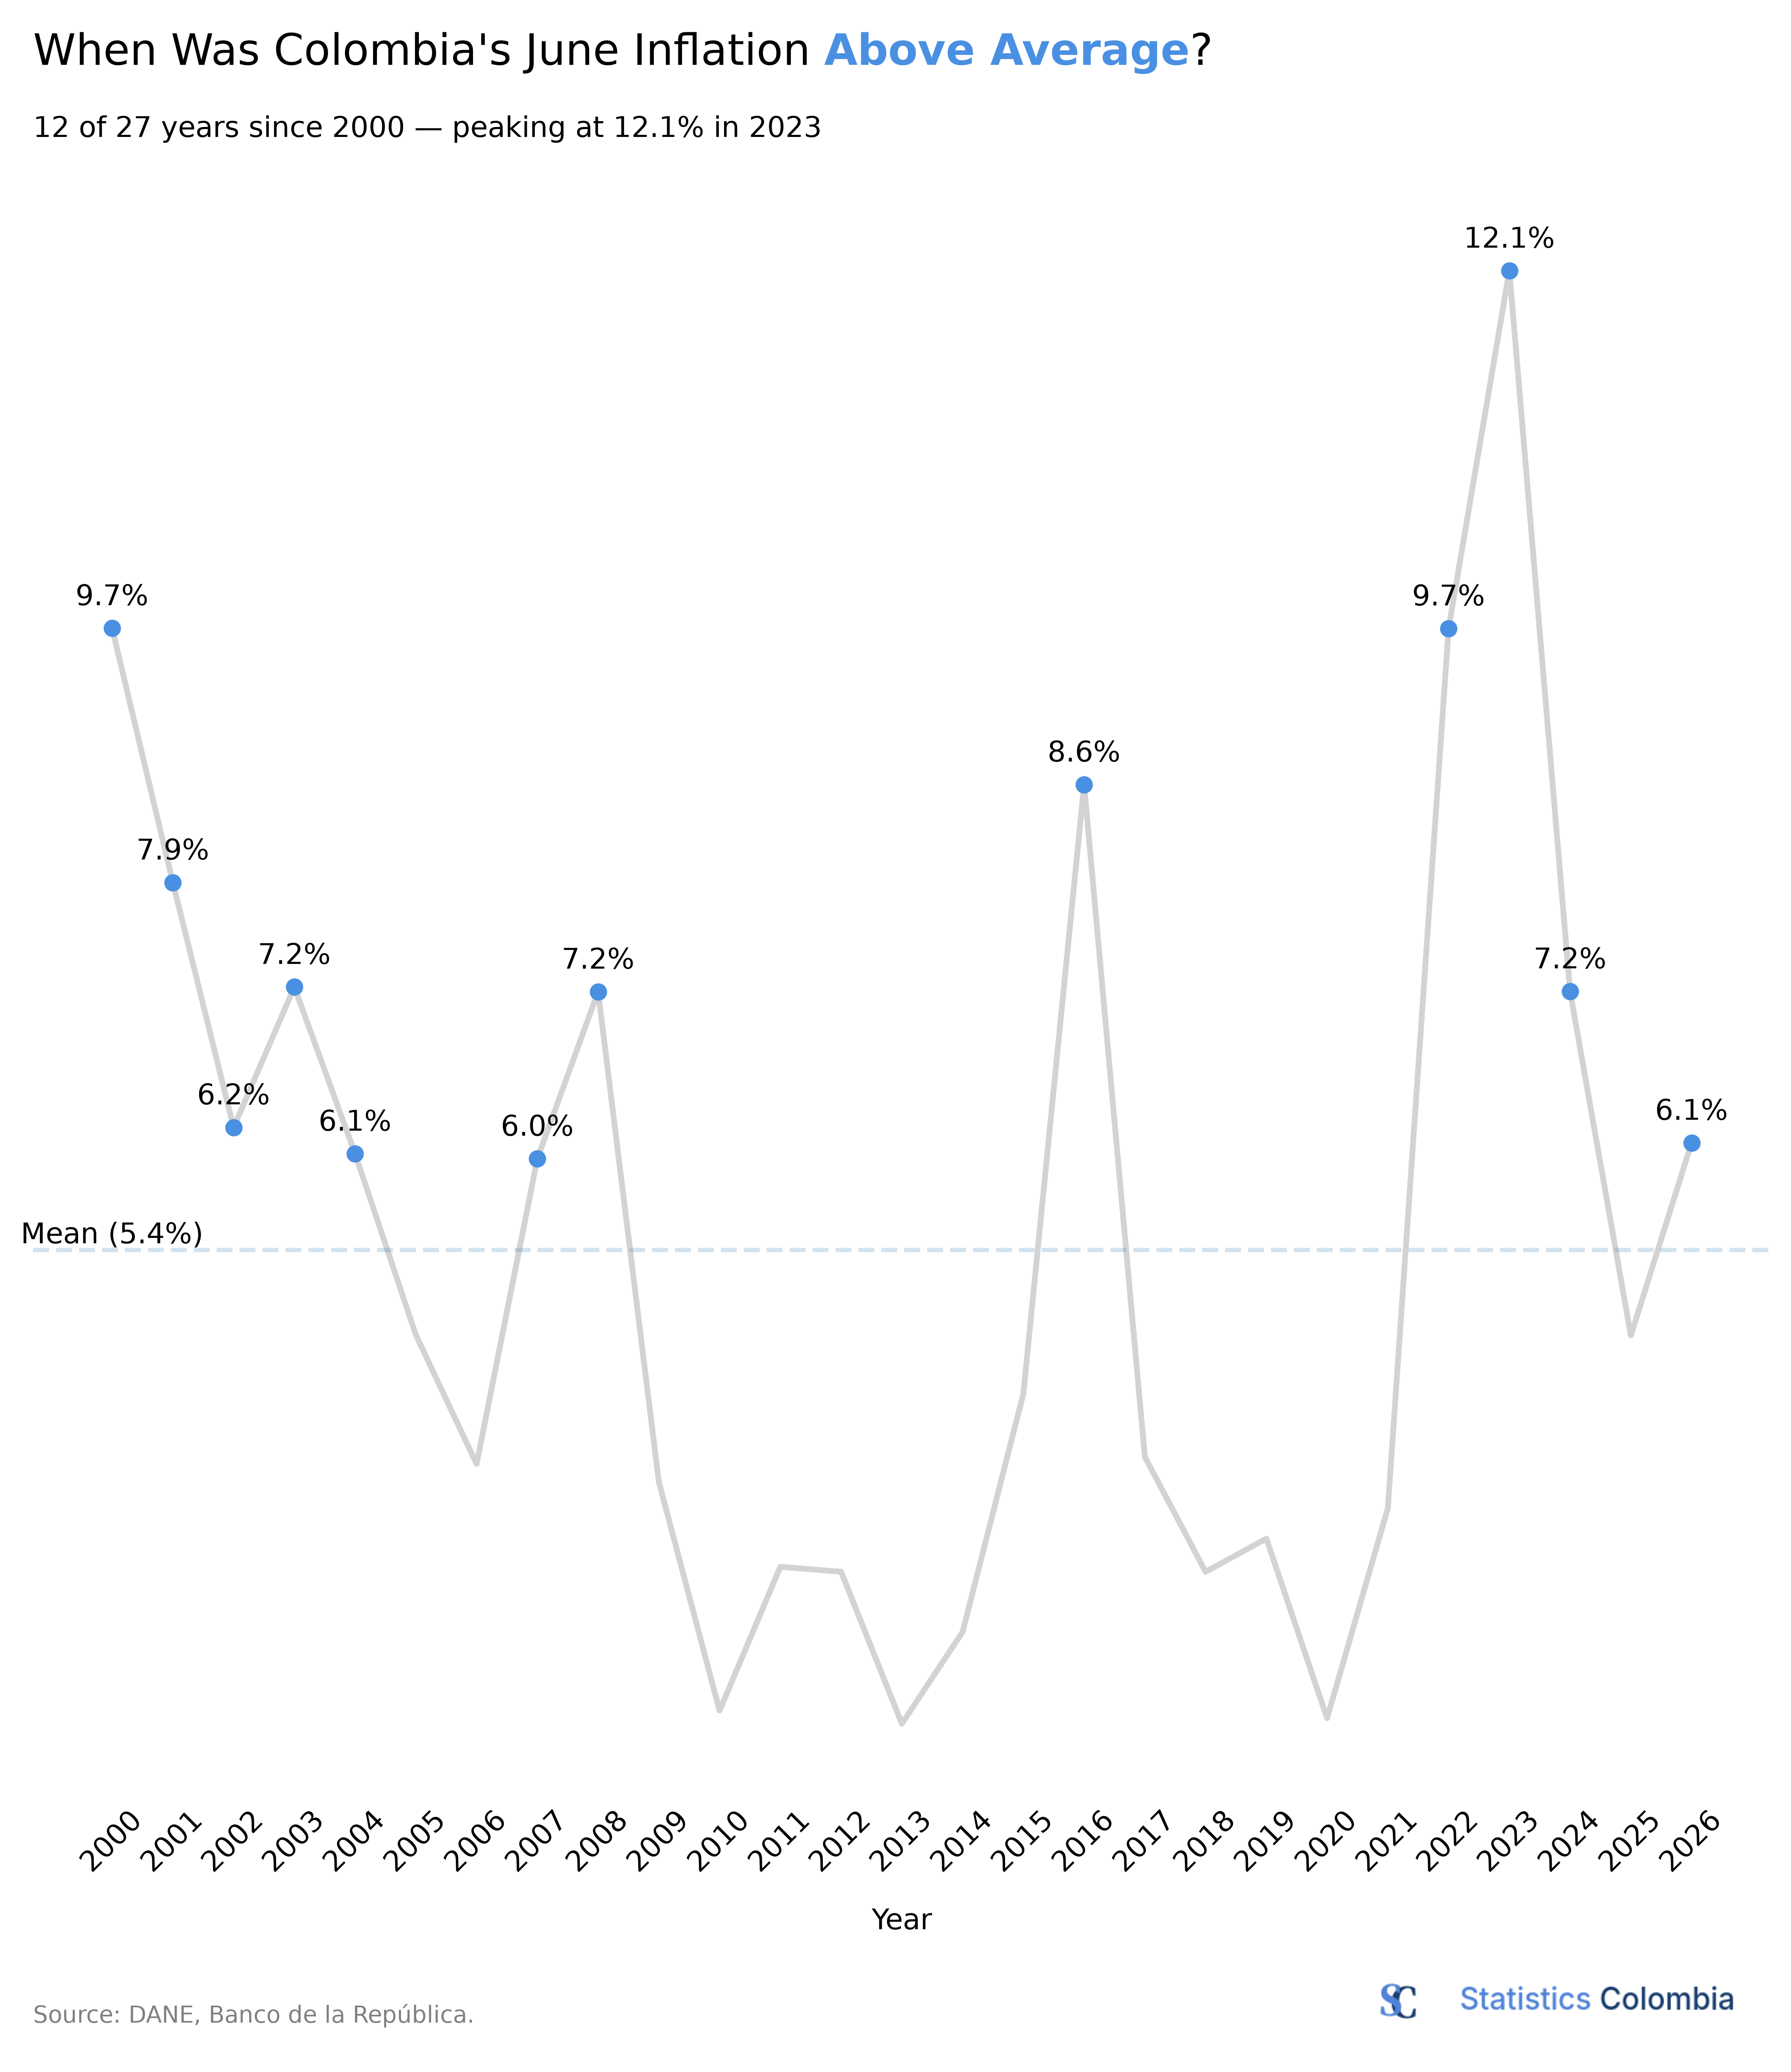

In [63]:
blue = "#4a90e2"
gray = "#D3D3D3"
years = df_f.index.tolist()
values = df_f["Variación anual (%)"].tolist()

plt.figure(figsize=(10.8, 10), dpi=500)

plt.plot(years, values, color=gray, linewidth=2)

for year, value in zip(years, values):
    if value >= threshold:
        plt.plot(year, value, marker="o", color=blue, markersize=5)
        plt.annotate(f"{value:.1f}%", xy=(year, value), textcoords="offset points", xytext=(0, 8), ha="center")

plt.axhline(y=threshold, linestyle="--", alpha=0.2)
plt.text(years[-1], threshold, f"Mean ({threshold:.1f}%)", va="bottom", ha="center")

plt.gca().yaxis.set_visible(False)
plt.xlabel("Year", labelpad=10, fontsize=10)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.xticks(years, rotation=45)

fig_text(
    0.125, 0.96,
    s="When Was Colombia's June Inflation <Above Average>?",
    highlight_textprops=[{"color": blue, "weight": "bold"}],
    fontsize=15
)

fig_text(
    0.125, 0.92,
    s="12 of 27 years since 2000 — peaking at 12.1% in 2023",
    fontsize=10
)

fig_text(
    0.125, 0.01, 
    "Source: DANE, Banco de la República.\n", 
    fontsize=8, color="gray",
)

imagebox = OffsetImage(logo, zoom=0.4)

ab = AnnotationBbox(imagebox, xy=(0.7, 0.035), xycoords='figure fraction',
                    frameon=False, pad=0)

plt.gca().add_artist(ab)

plt.show()